<a href="https://colab.research.google.com/github/olchan/Samsung-Coding-TEST/blob/main/%5B%EC%9D%B4%EC%BD%94%ED%85%8C%5D_DFS_BFS_PART2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 탐색 search
- 많은 양의 data 중에서 원하는 data를 찾는 과정
- 그래프, 트리 등의 자료구조 안에서 탐색을 하는 문제를 다룬다.
- DFS/ BFS : "그래프를 체계적으로 탐색(traverse)하는 것" -> **그래프의 모든 노드를 방문하기 위한 하나의 탐색 방법**


# BFS / DFS 문제의 keyword : 연결된 영역, 최단 거리, 퍼져나감, 탐색

# DFS / BFS : 탐색 알고리즘

> DFS / BFS를 이해하기 위해서는 Stack & Queue에 대한 이해가 있어야 한다.



In [ ]:
# stack

stack = []

# 데이터 넣기 (O(1))
stack.append(1)
stack.append(2)
stack.append(3)

# 데이터 빼기 (O(1))
print(stack.pop()) # 결과: 3
print(stack.pop()) # 결과: 2

💡 왜 Queue는 그냥 리스트를 안 쓰는 것일까?

- 리스트에서도 list.pop(0) 을 쓰면 맨 앞의 데이터를 뺄 수 있다. 하지만 리스트 pop(0)는 맨 앞을 빼면 뒤에 있는 모든 데이터를 한 칸씩 앞으로 당겨야 하므로 $O(N)$ 의 시간이 걸린다. 그렇기에, 데이터가 많아질수록 매우 느려진다.

- deque.popleft()는 **양방향 연결 리스트 구조를 사용하기 때문에** 데이터를 빼고 나서 당길 필요가 없다. 항상 $O(1)$ 의 빠른 속도를 보장한다.

In [ ]:
# Queue

from collections import deque

queue = deque()

# 데이터 넣기 (O(1))
queue.append(1)
queue.append(2)
queue.append(3)

# 데이터 빼기 (O(1))
print(queue.popleft()) # 결과: 1
print(queue.popleft()) # 결과: 2

> DFS / BFS를 이해하기 위해서는 재귀함수에 대한 이해가 있어야 한다.

- 재귀 함수는 내부적으로 동작하는 구조가 Stack 자료구조와 동일하다보니, **Stack 구조를 활용해야하는 상당수의 알고리즘은 재귀 함수를 이용해서 간편하게 구현 가능하다는 특징이 있다.**

- 재귀 함수는 특정한 함수를 자신보다 더 작은 변수에 대한 함수와의 관계로 표현한 점화식을 그대로 코드로 옮겼기에, 코드가 더욱 간결하다는 특징이 있다.

In [ ]:
# 마찬가지로, DFS 또한 재귀 함수를 이용해서 간편하게 구현 가능하다.

In [ ]:
end = 0

def recursive_function():
  global end
  end += 1
  if end > 5:
    return
  # 재귀 함수에는 무조건 종료 조건이 있어야 한다.
  print("Calling Recursive Function")
  recursive_function()

recursive_function()

Calling Recursive Function
Calling Recursive Function
Calling Recursive Function
Calling Recursive Function
Calling Recursive Function


# Graph

- 노드(vertex)와 간선(edge)로 구성된 자료 구조

- 인접 행렬 : 2차원 배열로 그래프의 연결 관계를 표현하는 방식
- 인접 리스트 : 리스트로 그래프의 연결 관계를 표현하는 방식

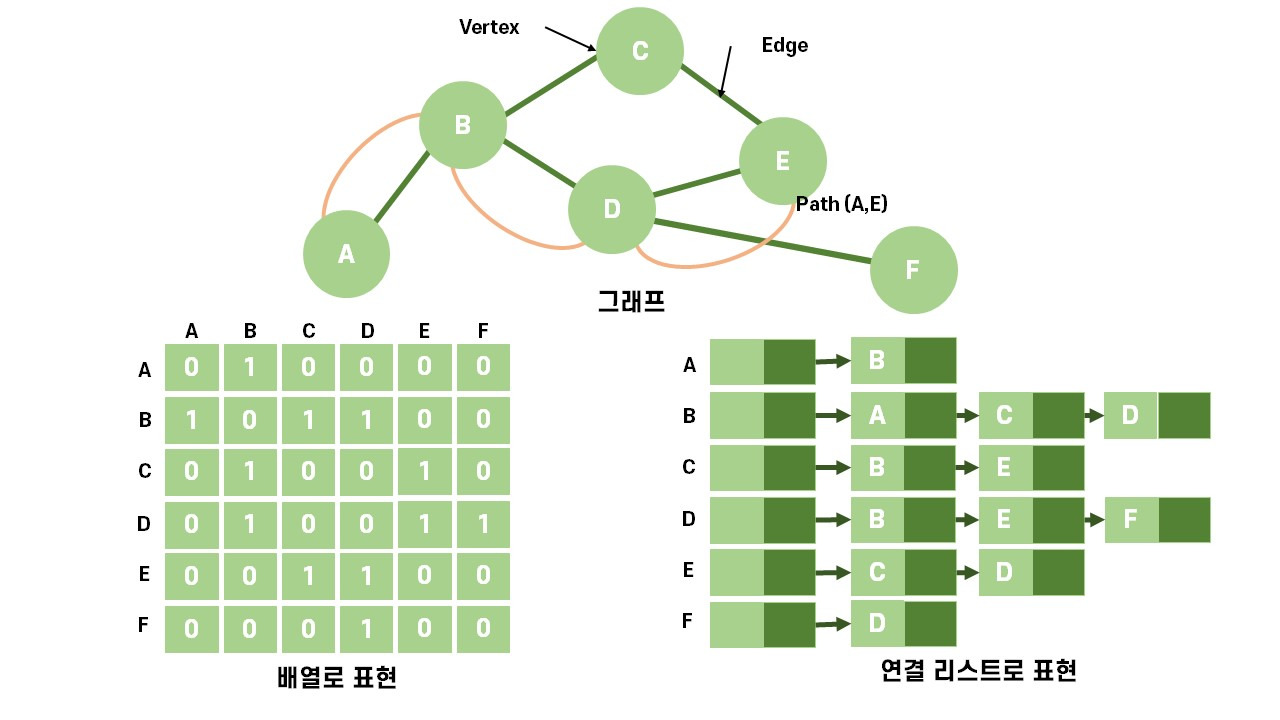

In [ ]:
# 인접 행렬
# 연결되어 있지 않은 노드끼리는 INF의 비용

INF = 99999
graph = [
    [0,7,5],
    [7,0,INF],
    [5,INF, 0]
]
"""
모든 관계를 저장하므로 노드 개수가 많은데 edge는 적을수록 메모리가 불필요하게 낭비됨
"""

In [ ]:
# 인접 리스트
# linked list를 이용하여 구현
# 다른 언어들과는 다르게 python의 기본 list는 append와 같은 메서드를 지원하기에
# 단순히 2차원 list로 인접 리스트를 구현 가능하다

graph = [[]for _ in range(3)]
# (연결된 노드, 거리)
graph[0].append((1,7))
graph[0].append((2,5))
graph[1].append((0,7))
graph[2].append((0,5))
graph

"""
인접 행렬에 비해 메모리를 효율적으로 사용
다만, 인접 리스트 방식의 경우, 인접 행렬 방식에 비해 특정한 두 노드 사이의 연결 여부를
알아내는 데에 걸리는 속도가 느리다. 연결된 노드들을 모두 확인해야하기 때문이다.
"""

[[(1, 7), (2, 5)], [(0, 7)], [(0, 5)]]

# DFS : Stack & BFS : Queue

> # DFS : Depth First Search

- graph에서 깊은 곳을 우선적으로 탐색하는 알고리즘

- STEP1. 탐색 시작 노드를 스택에 삽입(push)하고 방문 처리를 한다.
- STEP2. 스택의 top 노드에서 인접 노드를 탐색하여, 아직 방문하지 않은 노드를 발견했다면, stack에 push하고 즉시 방문 처리
- STEP3. STEP2를 더 이상 수행할 수 없을 떄까지 반복한다.

> visited(방문 처리)는 "실제로 방문했다"기보다는 "이미 발견(discovered)된 노드이기에 다시 후보로 넣지 않음"이라는 의미에 가깝습니다. 즉 스택에 들어간 순간 = 방문 예정이므로 visited 처리를 합니다.



> **DFS 노드의 3가지 상태** : 노드는 발견(discovered) → 탐색 → 종료(finished)의 세 단계를 가진다.

| 상태                        | 의미                 |
| ------------------------- | ------------------ |
| **undiscovered**          | 아직 한 번도 발견되지 않은 노드 |
| **discovered (visiting)** | 발견되어 탐색 중인 노드      |
| **finished**              | 모든 인접 노드 탐색이 끝난 노드 |


In [7]:
# 탐색 : O(N)

# DFS 메서드 정의
def dfs(graph, v, visited):
    # 현재 노드를 방문 처리
    visited[v] = True
    print(v, end=' ')

    # 현재 노드와 연결된 다른 노드를 재귀적으로 방문
    for i in graph[v]:
        if not visited[i]:
            dfs(graph, i, visited)


# 각 노드가 연결된 정보를 리스트 자료형으로 표현 (2차원 리스트)
graph = [
    [],
    [2, 3, 8],
    [1, 7],
    [1, 4, 5],
    [3, 5],
    [3, 4],
    [7],
    [2, 6, 8],
    [1, 7]
]

# 각 노드가 방문된 정보를 리스트 자료형으로 표현 (1차원 리스트)
visited = [False] * 9

# 정의된 DFS 함수 호출
dfs(graph, 1, visited)

1 2 7 6 8 3 4 5 

> ### **DFS는 Stack과 재귀 2가지 방법으로 구현 가능한데, 보통은 재귀를 이용해서 구현한다.**

In [3]:
# 재귀 DFS

graph = {
    'A': ['B', 'C'],
    'B': ['D'],
    'C': ['D'],
    'D': []
}

visited = set()

def dfs(node):
    visited.add(node)
    print("enter:", node)

    for next_node in graph[node]:
        if next_node not in visited:
            dfs(next_node)

    print("exit:", node)

dfs('A')

enter: A
enter: B
enter: D
exit: D
exit: B
enter: C
exit: C
exit: A


In [1]:
# Stack 구조를 활용한 DFS
graph = {
    'A': ['B', 'C'],
    'B': ['D'],
    'C': ['D'],
    'D': []
}

stack = [] # 앞으로 탐색할 노드들을 저장하는 스택
visited = set() # 이미 발견되어 스택에 들어갔던 노드를 기록 (중복 방지)
# discovered의 의미이지만, 보통 visited로 많이 사용한다.

stack.append('A')
visited.add('A')

while stack:
    node = stack.pop()
    print(node)

    for next_node in graph[node]:
        if next_node not in visited:
            stack.append(next_node)
            visited.add(next_node)


"""
재귀를 쓰는 DFS 와 차이가 존재
: 현재 노드의 모든 이웃을 stack에 넣기에,
실제 탐색 순서는 동일하지만 같은 depth의 노드가 먼저 visited(discovered)에 들어가게 된다.
BUT 실제 방문은 이후에!
"""

A
C
D
B


> 위상 정렬 : 선행 관계(의존 관계)가 있는 작업들을 그 조건을 위배하지 않도록 순서대로 나열하는 것

- DFS에서 “재귀가 끝나는 순간(post-order)”에 노드를 스택에 넣으면, 선행 작업이 자동으로 나중에 쌓입니다. 그래서 마지막에 스택을 뒤집으면 올바른 위상 정렬이 됩니다.

In [6]:
graph = {
    'A': ['B', 'C'],
    'B': ['D'],
    'C': ['D'],
    'D': []
}

visited = set()
result = []

def dfs(node):
    visited.add(node)

    for next_node in graph[node]:
        if next_node not in visited:
            dfs(next_node)

    result.append(node)   # 재귀 끝날 때 저장

for node in graph:
    if node not in visited:
        dfs(node)

print(result[::-1])

['A', 'C', 'B', 'D']


> # BFS : Breadth First Search

- BFS는 보통 재귀로 쓰지 않습니다. 거의 항상 queue로 구현합니다.
- from collections import deque를 사용 : queue = deque([start])
- queue.append() & queue.popleft()

> - Step1. 탐색 시작 노드를 queue에 삽입해서 방문(발견) 처리
> - Step2. queue에서 popleft를 해서 해당 노드의 인접 노드 중에서 방문(발견)하지 않은 노드를 모두 queue에 append하고 방문 처리
> - Step3. Step2에서 더 이상 queue에 넣을 방문하지 않은 인접 노드가 없을 떄까지 반복

In [ ]:
# BFS 탐색의 시간 복잡도 : O(N)
d = deque(maxlen=3)

# 빈 큐 생성 후 추가
queue = deque()
queue.append(3)

# 생성과 초기화를 동시에
queue = deque([3])

d.append(1) # : 오른쪽(뒤)에 데이터를 추가합니다.
d.popleft() # : 왼쪽(앞)에서 데이터를 하나 뽑아서 반환합니다.

In [ ]:
from collections import deque

def bfs(graph, start, visited):
    queue = deque([start])
    visited[start] = True

    while queue:
        v = queue.popleft()
        print(v, end = " ")
        for i in graph[v]:
            if not visited[i]:
                queue.append(i)
                visited[i] = True

# 각 노드가 연결된 정보를 리스트 자료형으로 표현(2차원 리스트)
graph = [
    [],
    [2, 3, 8],
    [1, 7],
    [1, 4, 5],
    [3, 5],
    [3, 4],
    [7],
    [2, 6, 8],
    [1, 7]
]

visited = [False] * 9
bfs(graph, 1, visited)

> ### Tip : 배열 문제를 “그래프 탐색 문제”로 생각하면 DFS/BFS로 쉽게 풀 수 있다.

In [ ]:
# 1️⃣ 2차원 배열을 그래프로 보는 경우
1 1 0
0 1 0
1 0 1

# 각 칸을 노드(node) 로 보고
# 상하좌우를 간선(edge) 으로 봐서 그래프처럼 생각
(0,0) (0,1) (0,2)
(1,0) (1,1) (1,2)
(2,0) (2,1) (2,2)

# ex) 섬(이어진 땅)의 개수 문제
# 연결된 1들을 DFS로 탐색


# Min Heap : Complete Binary Tree + only Order
매번 O(NlogN)의 시간 복잡도로 정렬 상태를 유지하거나 아니면, 그냥 O(1)로 아무렇게나 넣어두고 뺄 때는 가장 작은 값을 O(N)의 시간 복잡도로 뺄 수 있지만, heapq 라이브러리를 사용하면 완전 이진 트리 구조를 유지하면서 상향식 재배치 과정을 거치기에, data 삽입과 삭제를 모두 O(logN)의 복잡도로 수행한다.

In [ ]:
# Heap

import heapq

priority_q = []
heapq.heappush(priority_q, 3)
heapq.heappush(priority_q, 1)
heapq.heappush(priority_q, 4)

priority_q

[1, 3, 4]

> ### **실전문제 3. 음료수 얼려 먹기**

In [ ]:
n, m = map(int, input().split())
ice_map = []
for _ in range(n):
    ice_map.append(list(map(int, input().strip())))

def dfs(r : int, c : int):
    ice_map[r][c] = 1
    # x:행   y :열
    dr = [-1, 1, 0, 0]
    dc = [0, 0, -1, 1]

    for i in range(4):
        new_r = r + dr[i]
        new_c = c + dc[i]
        if (0 <= new_r < n) and (0 <= new_c < m):
            if ice_map[new_r][new_c] == 0:
                dfs(new_r, new_c)


count_ice_num = 0
for i in range(n):
    for j in range(m):
        if ice_map[i][j] == 0:
            count_ice_num += 1
            dfs(i,j)

print(count_ice_num)

# **List 복사 or 2차원 list 생성 시 주의사항**


> **Python에서 변수에는 값이 들어있는 것이 아니라 객체를 가리키는 reference(c++의 메모리 주소와는 다르지만, 객체를 가리키는 이름표)가 저장되어 있습니다. -> JUST 객체를 가리키는 이름**


In [ ]:
# mutable : 객체에 변화가 생겨도 그 객체의 주소 자체는 변화하지 않고, 유지되는 것

a = [1,2,3]
b = a
# 이 코드에서는 list가 복사된 것이 아니라
# 같은 객체([1,2,3])를 두 변수가 가리킵니다.
b[0] = 10 # 을 하게 되면
print(a) # a의 값도 바뀌게 된다.
"""
[1,2,3]은 객체 내부를 수정할 수 있기에, b에서 변화를 주게 되면 a도 같이 가리키고 있던
객체에 변화가 생기면서 a까지도 변화가 생기는 것.
"""

[10, 2, 3]


In [ ]:
# immutable(객체 자체를 수정할 수 없음)이라면?
# immutable : 수정할 수 없기 때문에 기존 객체의 주소가 바뀌는 것이 아니라
# 값이 바뀌는 경우 새로운 객체가 생성되고
# 변수가 그 새로운 객체를 가리키게 된다.
# 즉, 변수가 가리키는 객체(reference)가 변화하는 것

a = 3
b = a
b = 5
a

"""
객체 3은 그대로 있고, b가 새로운 객체 5를 가리키게 되는 것.
"""

3

In [ ]:
a = [1,2,3]
b = a
a = a + [4] # +는 원본 객체를 수정하는 것이 아닌 새 리스트 생성
print(b)

a = [1,2,3]
b = a
a.append(4) # append는 기존 리스트 수정
print(b)

[1, 2, 3]
[1, 2, 3, 4]


In [ ]:
###### 2차원 list의 복사 ######

map = [[1,2,3], [4,5,6], [7,8,9]]
map_copy = map # 처럼 하게 되면, 동일한 객체를 가리키는 또 다른 reference를 만드는 것

map_copy_new = [row[:] for row in map]
# Slicing을 쓰게 되면, 새 리스트 객체를 만든다.
# 다만, slicing은 shallow copy
# Why shallow Copy? python의 list는 객체의 reference를 저장하고 있기 때문이다.
"""
a ──► [ ref1 , ref2 , ref3 ]
          │      │     │
          ▼      ▼     ▼
          10      20     30
"""

b = a[:] # 를 하면,
# 1️⃣ 새 리스트를 만든다
# 2️⃣ 기존 리스트의 reference들을 복사해서 넣는다

"""
a ──► [ ref1 , ref2 , ref3 ]
b ──► [ ref1 , ref2 , ref3 ]
"""
# 다음과 같이, 리스트 객체는 다른데 동일한 reference의 객체를 보관하고 있음
# 그렇다보니, 리스트 안에 또 다른 리스트가 있는 2차원 list를 복사하는 경우에는

a = [[1,2], [3,4]]
b = a[:]
"""
바깥 리스트만 새로운 객 & 안쪽 리스트는 공유
a ──► [ refA , refB ]
b ──► [ refA , refB ]

refA ─► [1,2]
refB ─► [3,4]
"""
# 그렇기에,
b[0][0] = 100 # 을 하면
# a [[100,2],[3,4]]가 된다.

# 결론 : slicing은 바깥 리스트만 복사하고 내부 객체는 reference로 공유된다.
# 그래서 내부 요소가 immutable이면 문제가 없지만 mutable이면 같이 바뀔 수 있다.
# 따라서, 복사되는 것이 immutable한 단계에서만 slicing을 해야 n차원 배열의 복사에서 문제가 생기지 않는다.

"""
올바른 2차원 배열 복사 : List Comprehension을 사용하여 immutable한 reference 대상을 복사
copy = [row[:] for row in arr]
"""

> **List Comprehension을 쓰지 않으면 생기는 문제**

- *n : 객체를 n개 복사하는 게 아니라, [ ] 안의 객체에 대한 “참조(reference)”를 n번 반복하여 해당 객체가 n개 있는 list를 만드는 것

In [ ]:
list_2d = [[0]*3]*5
"""
[0]*3 은 [0]이 복사되는 것이 아니라
0이라는 객체를 가리키는 reference가 3번 들어간 리스트가 만들어지는 것
"""

list_2d[0][0] = 1
print(list_2d)

# [[0]*3]*5 는 [0,0,0] 리스트 객체 하나를 만들고, 그 객체의 reference를 5번 복사한 것입니다.
"""
listA ─► [ ref0 , ref0 , ref0 ]
            │      │      │
            ▼      ▼      ▼
            0       0       0

list_2d ─► [ refA , refA , refA , refA , refA ]
             │      │      │      │      │
             ▼      ▼      ▼      ▼      ▼
           [0,0,0] [0,0,0] [0,0,0] [0,0,0] [0,0,0]
"""

[[1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0], [1, 0, 0]]


In [ ]:
# List를 3번 복사하는 것이 아니라, [0] 객체 하나를 3번 참조하는 것
a = [[0]]*3
print(a)
a[0][0] = 3
print(a)

[[0], [0], [0]]
[[3], [3], [3]]


In [ ]:
"내부 값을 바꾸는 것은 같은 객체를 수정하는 것이고"
"a[0] = 3은 객체를 바꾸는 게 아니라, 그 위치의 참조를 다른 객체로 교체하는 것이다."

a = [[0]]*3
print(a)
a[0] = [3] # 가장 중요한 것은 객체를 직접 수정한 것인지 (mutation)
# 아니면 참조를 다른 객체로 교체한 것인지 (re-binding) 이다.
print(a)

[[0], [0], [0]]
[[3], [0], [0]]


>> 2차원 list 초기화에는 [[0]*m for _ in range(n)] 처럼 사용한다.

In [ ]:
row = [[0]*m for _ in range(n)]
# [0]*m 은 immutable한 정수 0을 m번 참조하는 리스트를 만든다.
# 정수는 immutable이므로 row[0][0] = 5 는 기존 0을 수정하는 것이 아니라,
# 해당 위치의 참조가 새로운 객체 5로 변경되는 것이다.
# 또한 리스트 컴프리헨션으로 각 행이 별도의 리스트 객체로 생성되기 때문에
# 다른 행에는 영향을 주지 않는다.

In [ ]:
row = [[0]*3 for _ in range(4)]
row[0][0] = 5
row

[[5, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0]]

> ### **실전문제 4. 미로 탈출**

In [ ]:
# 초기 코드 : DFS로 시도
# DFS로는 경로로 향하는 길을 찾을 수는 있지만 그것이 최단 거리임은 보장을 하지 않음.

n, m = map(int, input().split())
miro = []

for _ in range(n):
    miro.append(list(map(int,input().strip())))

right_way_num = 0

def dfs(r, c):
    global right_way_num
    if right_way_num == 0:
        r = r-1
        c = c-1
    # 방문 표시
    miro[r][c] = 0
    right_way_num += 1

    if r == n-1 and c == m-1:
        print(right_way_num)
    # 동 남 서 북
    dr = [0, 1, 0 , -1]
    dc = [1, 0, -1 , 0]

    for i in range(4):
        next_r = r + dr[i]
        next_c = c + dc[i]
        if (0 <= next_r < n) and (0<= next_c < m):
            if miro[next_r][next_c] == 1:
                dfs(next_r, next_c)

    right_way_num -= 1

dfs(1,1)

In [ ]:
# BFS 로 code를 작성하게 되면, 가장 처음 목적지에 도달했을 때의 경로가 최소 거리 경로임을 보장
# IDEA : 특정한 노드를 방문하면 이전 노드까지 걸렸던 최소 거리에 +1을 해준값으로 update

from collections import deque

n, m = map(int, input().split())
miro = []

for _ in range(n):
    miro.append(list(map(int, input().strip())))

def bfs():
    queue = deque()
    queue.append((0,0))
    # 동 서 남 북
    dr = [0, 0, 1, -1]
    dc = [1, -1, 0, 0]
    while queue:
        r, c = queue.popleft()
        for i in range(4):
            new_r = r + dr[i]
            new_c = c + dc[i]
            if 0 <= new_r < n and 0 <= new_c < m:
                if miro[new_r][new_c] == 1:
                    miro[new_r][new_c] = miro[r][c] + 1
                    queue.append((new_r, new_c))
                    if new_r == n-1 and new_c == m-1:
                        print(miro[new_r][new_c])
                        return
bfs()